# Policy Iteration

Policy iteration is a DP algorithm to find the optimal policy.

In [3]:
#@title Imports
import numpy as np
import matplotlib.pyplot as plt

### Grid World

![](https://drive.google.com/uc?export=view&id=1yrkvRaDqwHurt23OPTGhaDcuuE4hBFxv)


In [6]:
#@title Grid World
m, n = 4, 4
# states
S = [(r, c) for r in range(m) for c in range(n)]
# actions
A = ['north', 'south', 'east', 'west']
# number of actions
acount = len(A)
# terminal states
terminal = [(0, 0), (3,3)]
# discounting
gamma = 1

In [4]:
#@title Transitions
# s = (r, c)
# r -> row, c -> column
def transition(s, a, s_next):
    r, c = s
    if a == 'north':
        r = r if r == 0 else r - 1
    if a == 'south':
        r = r if r == m - 1 else r + 1
    if a == 'west':
        c = c if c == 0 else c - 1
    if a == 'east':
        c = c if c == n - 1 else c + 1
    # deterministic transition
    prob = 1 if (r, c) == s_next else 0
    # constant reward for all time steps
    reward = -1
    # return probability and reward
    return prob, reward

### Policy

We will evaluate the value function for an equiprobable random policy:

$$
\begin{aligned}
\pi(\text{north}\ |\ s) &= 0.25\\
\pi(\text{east}\ |\ s) &= 0.25\\
\pi(\text{west}\ |\ s) &= 0.25\\
\pi(\text{south}\ |\ s) &= 0.25
\end{aligned}
$$

In [7]:
#@title Policy
pi = {s: {a: 0.25 for a in A} for s in S}

## Policy Evaluation

We will look at two kinds of updates:

- synchronous
- in-place

The update rule is as follows:

$$
v_{k+1}(s) := \sum \limits_{a} \pi(a\ |\ s) \sum \limits_{s^{\prime}, r} p(s^{\prime}, r\ |\ s, a) \Big [ r + \gamma v_k(s^{\prime}) \Big]
$$

This can also be written as:

$$
v_{k+1}(s) := \sum \limits_{a} \pi(a\ |\ s) \sum \limits_{s^{\prime}} p(s^{\prime}\ |\ s, a) \Big [ r(s, a, s^{\prime}) + \gamma v_k(s^{\prime}) \Big]
$$

In [8]:
#@title Helper
def to_numpy(v, m, n):
    vnum = np.zeros((m, n))
    for s in v:
        vnum[s] = v[s]
    return vnum

In [9]:
#@title Policy Evaluation (synchronous)
# threshold for convergence
theta = 1e-3
delta = theta + 1
# value function for current time step
v = {s: 0 for s in S}
# iterations
iter = 0

# delta < theta => convergence
while delta >= theta:
    iter += 1
    # value function for next time step
    v_next = {s: 0 for s in S}
    # max difference in values
    delta = 0
    # one sweep through the state space
    for s in S:
        # the value of a terminal state remains zero
        if s in terminal:
            continue
        # take action a in state s
        for a in A:
            # transition to next state s_next
            for s_next in S:
                # prob, reward for this transition
                prob, reward = transition(s, a, s_next)
                v_next[s] += pi[s][a] * prob * (reward + gamma * v[s_next])
        delta = max(delta, abs(v[s] - v_next[s]))
    # update the value for the current time step
    print(iter, v[(2, 1)])
    v = v_next.copy()
v = {s: np.round(v[s]) for s in S}

print(f'Number of iterations for convergence = {iter}')
print('Value function rounded off to nearest integer')
to_numpy(v, m, n)

1 0
2 -1.0
3 -2.0
4 -3.0
5 -3.90625
6 -4.78125
7 -5.58984375
8 -6.3642578125
9 -7.08837890625
10 -7.778564453125
11 -8.427825927734375
12 -9.044876098632812
13 -9.627132415771484
14 -10.179577827453613
15 -10.701705932617188
16 -11.19663405418396
17 -11.664792448282242
18 -12.108329176902771
19 -12.528060752898455
20 -12.92560236249119
21 -13.301895371172577
22 -13.658238352742046
23 -13.99557680657017
24 -14.315002881266992
25 -14.617413416581257
26 -14.90375276602299
27 -15.174848747057695
28 -15.431531175373038
29 -15.674553684982726
30 -15.904652073440758
31 -16.122507513544274
32 -16.32877569970972
33 -16.524069963174888
34 -16.708976208182204
35 -16.88404555473037
36 -17.049802318792327
37 -17.20674117692924
38 -17.35533170570789
39 -17.496017657293095
40 -17.629219765172493
41 -17.75533597316491
42 -17.8747433398552
43 -17.987798668448256
44 -18.094839918796183
45 -18.196186977229964
46 -18.29214277968436
47 -18.3829941009879
48 -18.469012492717752
49 -18.550455038688042
50 -18.

array([[  0., -14., -20., -22.],
       [-14., -18., -20., -20.],
       [-20., -20., -18., -14.],
       [-22., -20., -14.,   0.]])

In [10]:
#@title Policy Evaluation (in-place)
def evaluate(pi):
    # threshold for convergence
    theta = 1e-3
    delta = theta + 1
    # value function for current time step
    v = {s: 0 for s in S}
    # iterations
    iter = 0

    # delta < theta => convergence
    while delta >= theta:
        iter += 1
        # max difference in values
        delta = 0
        # one sweep through the state space
        for s in S:
            vs = 0
            # the value of a terminal state remains zero
            if s in terminal:
                continue
            # take action a in state s
            for a in A:
                # transition to next state s_next
                for s_next in S:
                    # prob, reward for this transition
                    prob, reward = transition(s, a, s_next)
                    vs += pi[s][a] * prob * (reward + gamma * v[s_next])
            delta = max(delta, abs(v[s] - vs))
            # update the value for the current state
            v[s] = vs
    return v, iter
v, iter = evaluate(pi)
v = {s: np.round(v[s]) for s in S}
print(f'Number of iterations for convergence = {iter}')
print('Value function rounded off to nearest integer')
to_numpy(v, m, n)

Number of iterations for convergence = 88
Value function rounded off to nearest integer


array([[  0., -14., -20., -22.],
       [-14., -18., -20., -20.],
       [-20., -20., -18., -14.],
       [-22., -20., -14.,   0.]])

In [ ]:
#@title Policy Improvement
def improve(v):
    # new deterministic policy
    pi_next = {s: {a: 0 for a in A} for s in S}
    # action values for current policy
    q = {s: {a: 0 for a in A} for s in S}
    for s in S:
        for a in A:
            for s_next in S:
                prob, reward = transition(s, a, s_next)
                q[s][a] += prob * (reward + gamma * v[s_next])
        amax = max([(a, q[s][a]) for a in A], key = lambda x: x[1])[0]
        pi_next[s][amax] = 1
    return pi_next

pi_next = improve(v)
pi_next

{(0, 0): {'north': 1, 'south': 0, 'east': 0, 'west': 0},
 (0, 1): {'north': 0, 'south': 0, 'east': 0, 'west': 1},
 (0, 2): {'north': 0, 'south': 0, 'east': 0, 'west': 1},
 (0, 3): {'north': 0, 'south': 1, 'east': 0, 'west': 0},
 (1, 0): {'north': 1, 'south': 0, 'east': 0, 'west': 0},
 (1, 1): {'north': 1, 'south': 0, 'east': 0, 'west': 0},
 (1, 2): {'north': 0, 'south': 1, 'east': 0, 'west': 0},
 (1, 3): {'north': 0, 'south': 1, 'east': 0, 'west': 0},
 (2, 0): {'north': 1, 'south': 0, 'east': 0, 'west': 0},
 (2, 1): {'north': 1, 'south': 0, 'east': 0, 'west': 0},
 (2, 2): {'north': 0, 'south': 1, 'east': 0, 'west': 0},
 (2, 3): {'north': 0, 'south': 1, 'east': 0, 'west': 0},
 (3, 0): {'north': 1, 'south': 0, 'east': 0, 'west': 0},
 (3, 1): {'north': 0, 'south': 0, 'east': 1, 'west': 0},
 (3, 2): {'north': 0, 'south': 0, 'east': 1, 'west': 0},
 (3, 3): {'north': 0, 'south': 1, 'east': 0, 'west': 0}}

In [ ]:
#@title Policy Iteration
pi_next = {s: {a: 1 / acount for a in A} for s in S}
pi = {s: {a: 1 if a == 'north' else 0 for a in A} for s in S}

iter = 0
while not np.array_equal(pi, pi_next):
    pi = pi_next.copy()
    v, _ = evaluate(pi)
    pi_next = improve(v)
    iter += 1

print(f'Number of iterations for convergence = {iter}')
to_numpy(v, m, n)

Number of iterations for convergence = 3


array([[ 0., -1., -2., -3.],
       [-1., -2., -3., -2.],
       [-2., -3., -2., -1.],
       [-3., -2., -1.,  0.]])

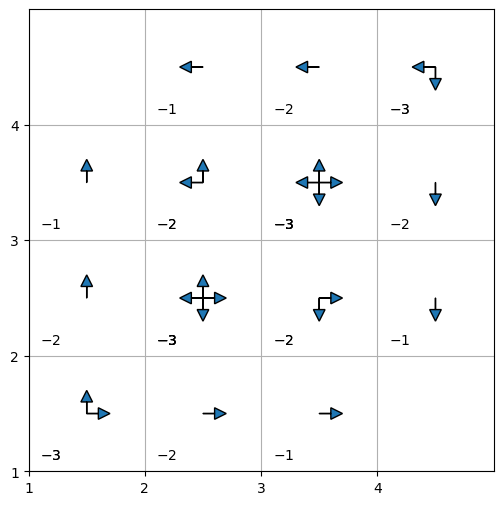

In [ ]:
#@title Optimal Policies
# Set plot for displaying optimal policy
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [6, 6]
ext = 0.1
arrow_map = {'north': (0, ext), 'south': (0, -ext),
             'east': (ext, 0), 'west': (-ext, 0)}

# Optimal action values
q = {s: {a: 0 for a in A} for s in S}
for s in S:
    if s in terminal:
        continue
    for a in A:
        for s_next in S:
            prob, reward = transition(s, a, s_next)
            q[s][a] += prob * (reward + gamma * v[s_next])
    # Get all optimal actions
    maxq = max([q[s][a] for a in A])
    opt_acts = [a for a in A if q[s][a] == maxq]
    for a in opt_acts:
        r, c = s
        x, y = c + 0.5, m - 1 - r + 0.5,
        plt.arrow(x, y, arrow_map[a][0], arrow_map[a][1],
                        head_width = 0.1, head_length = 0.1)
        plt.text(x - 0.4, y - 0.4, f'${v[s]}$')

# Setup grid for displaying the policies
plt.grid(True)
plt.xlim([0, n])
plt.ylim([0, m])
plt.xticks(np.arange(0, n, 1), np.arange(1, n + 1))
plt.yticks(np.arange(0, m, 1), np.arange(1, m + 1));

In [ ]:
v

{(0, 0): 0,
 (0, 1): -1,
 (0, 2): -2,
 (0, 3): -3,
 (1, 0): -1,
 (1, 1): -2,
 (1, 2): -3,
 (1, 3): -2,
 (2, 0): -2,
 (2, 1): -3,
 (2, 2): -2,
 (2, 3): -1,
 (3, 0): -3,
 (3, 1): -2,
 (3, 2): -1,
 (3, 3): 0}

In [ ]:
q[(1, 1)]['south']

-4